# CAZ Framework — What Happens Inside a Transformer?

*A layer-by-layer dissection of how a language model constructs semantic concepts*

When a transformer processes text, concepts like *negation*, *causation*, and *certainty* are not passively stored — they are built up across layers, in specific regions, through a measurable geometric process. The **Concept Allocation Zone (CAZ)** framework makes that process visible.

This notebook uses Llama-3.1-8B as a case study. [Llama Scope](https://arxiv.org/abs/2410.20526) (Chen et al., 2024) publishes 256 sparse autoencoders for this model — each trained independently at a single layer and sublayer position. Individual SAEs are designed to operate at one specific depth: the construction trajectory connecting layers is not represented in any of them. That gap is what CAZ addresses. No GPU required — all results are pre-computed.

The notebook works through the core ideas from first principles: the single-layer probing problem, the three CAZ signals, zone anatomy, multimodal allocation, and how the underlying concept *direction* evolves alongside the amplitude.

**[github.com/jamesrahenry/Rosetta](https://github.com/jamesrahenry/Rosetta)** · Henry (2026a–b)

In [1]:
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    _pip("rosetta_tools>=1.3.1")
except subprocess.CalledProcessError:
    _pip("rosetta_tools @ git+https://github.com/jamesrahenry/Rosetta_Tools.git@v1.3.1")

_pip("huggingface_hub", "matplotlib", "numpy", "scipy", "scikit-learn")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

HF_REPO = "james-ra-henry/Rosetta-Activations"
# Paper data (N=250, frozen at paper-n250 tag). Switch to "models" when full RCP is available.
HF_DATA_ROOT = "paper_n250"

# Llama-3.1-8B — Llama Scope (Chen et al., 2024) publishes SAEs at each individual layer
PRIMARY_MODEL = "meta-llama/Llama-3.1-8B"   # 32 layers, 4096-dim, GQA, SwiGLU, RoPE
PRIMARY_LABEL = "Llama-3.1-8B"

# Concepts available in the Rosetta Activations dataset
ALL_CONCEPTS = [
    "temporal_order", "causation", "agency",
    "negation", "sentiment", "moral_valence",
    "urgency", "certainty", "credibility",
    "sarcasm", "specificity",
]

def model_key(model_id: str) -> str:
    return model_id.replace("/", "_").replace("-", "_")

print("Setup complete.")

Setup complete.


In [3]:
from rosetta_tools.viz_style import (
    concept_color, CONCEPT_COLORS, FAMILY_COLORS, THEME, apply_theme,
)
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "figure.facecolor": "white",
})
print("Style loaded.")

Style loaded.


## Download pre-computed CAZ results

Pre-computed results for Llama-3.1-8B across eleven concepts are stored in the [Rosetta Activations](https://huggingface.co/datasets/james-ra-henry/Rosetta-Activations) dataset on Hugging Face. Each file contains, for every layer: Fisher separation $S(l)$, coherence $C(l)$, velocity $v(l)$, and the dominant concept direction $\hat{d}(l)$.

In [4]:
caz = {}
for concept in ALL_CONCEPTS:
    filename = f"{HF_DATA_ROOT}/{model_key(PRIMARY_MODEL)}/caz_{concept}.json"
    path = hf_hub_download(HF_REPO, filename=filename, repo_type="dataset")
    with open(path) as f:
        caz[concept] = json.load(f)

d0 = caz[ALL_CONCEPTS[0]]
print(f"Model:    {PRIMARY_LABEL}  ({d0['n_layers']} layers, {d0['hidden_dim']}-dim)")
print(f"Concepts: {len(caz)}  ({', '.join(ALL_CONCEPTS)})")

caz_temporal_order.json: 0.00B [00:00, ?B/s]

caz_causation.json: 0.00B [00:00, ?B/s]

caz_agency.json: 0.00B [00:00, ?B/s]

caz_negation.json: 0.00B [00:00, ?B/s]

caz_sentiment.json: 0.00B [00:00, ?B/s]

...

caz_certainty.json: 0.00B [00:00, ?B/s]

caz_credibility.json: 0.00B [00:00, ?B/s]

caz_sarcasm.json: 0.00B [00:00, ?B/s]

caz_specificity.json: 0.00B [00:00, ?B/s]

Model:    Llama-3.1-8B  (32 layers, 4096-dim)
Concepts: 11  (temporal_order, causation, agency, negation, sentiment, moral_valence, urgency, certainty, credibility, sarcasm, specificity)


## 1. The single-layer problem

The standard probing approach picks one layer and trains a classifier there. The implicit assumption is that concepts *live at* a layer — that there is some reliably good depth where all the signal you need has already crystallised. The plot below shows what actually happens.

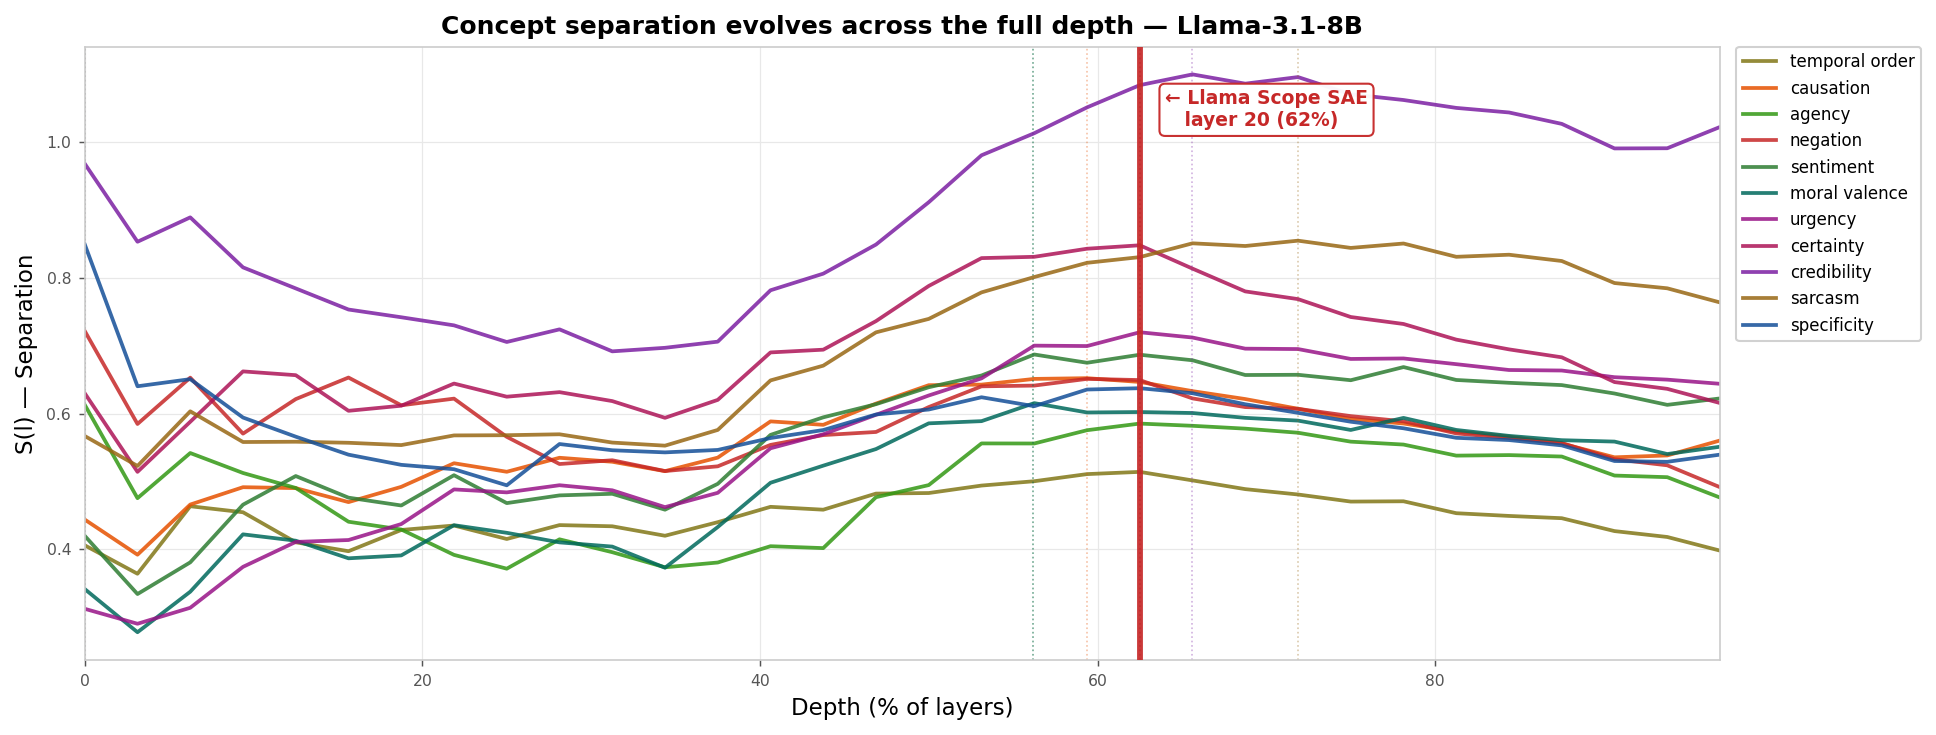

In [5]:
n_layers = caz[ALL_CONCEPTS[0]]["n_layers"]
max_depth = (n_layers - 1) / n_layers * 100

all_sep_vals = [m["separation_fisher"]
                for concept in ALL_CONCEPTS
                for m in caz[concept]["layer_data"]["metrics"]]
y_ceiling = max(all_sep_vals)

fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor("white")

for concept in ALL_CONCEPTS:
    metrics = caz[concept]["layer_data"]["metrics"]
    depth   = [m["layer"] / n_layers * 100 for m in metrics]
    sep     = [m["separation_fisher"] for m in metrics]
    peak    = caz[concept]["layer_data"]["peak_depth_pct"]
    color   = concept_color(concept)
    ax.plot(depth, sep, color=color, lw=1.8, alpha=0.85, label=concept.replace("_", " "))
    ax.axvline(peak, color=color, lw=0.8, ls=":", alpha=0.35)

# Llama Scope (Chen et al., 2024) — one SAE per layer, each trained on a single depth only.
# Layer 20 is one such model; see neuronpedia.org/llama3.1-8b/20-llamascope-res-32k
sae_layer = 20
sae_pct   = sae_layer / n_layers * 100
ax.axvline(sae_pct, color="#C62828", lw=2.8, zorder=5, alpha=0.92)
ax.text(sae_pct + 1.5, y_ceiling * 0.98,
        f"← Llama Scope SAE\n   layer {sae_layer} ({sae_pct:.0f}%)",
        color="#C62828", fontsize=9, fontweight="bold", va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#C62828", lw=1.0, alpha=0.96),
        zorder=6)

ax.set_xlabel("Depth (% of layers)", fontsize=11)
ax.set_ylabel("S(l) — Separation", fontsize=11)
ax.set_title(f"Concept separation evolves across the full depth — {PRIMARY_LABEL}",
             fontsize=12, fontweight="bold")
ax.set_xlim(0, max_depth)
ax.legend(fontsize=8, ncol=1, bbox_to_anchor=(1.01, 1), loc="upper left",
          borderaxespad=0, framealpha=0.9)
apply_theme(ax)
plt.tight_layout()
plt.show()

Concept representations are not assembled at a single point — they build, shift, and refine continuously across many layers. The S(l) curves above are broad distributions, not spikes. Most concepts are actively separating across a wide depth range rather than crystallising at one moment, and several peak at overlapping depths.

**[Llama Scope](https://arxiv.org/abs/2410.20526)** (Chen et al., 2024) publishes 256 sparse autoencoders for this model — one trained independently at each layer and sublayer position. Each SAE is designed to operate at a single depth: it learns features from the residual stream at one specific layer and cannot see activations at any other. The red line marks one such model (layer 20, 62% depth). In the chart above that corresponds to a single vertical slice: the SAE captures the state of representations at that depth, but the construction trajectory on either side — and all the dynamics above — are outside its view.

This is not a criticism of the approach; it is a description of what the tool is designed to do. The zone-based approach asks a different question. Instead of *what features exist at layer L*, it asks *over what depth range is each concept being actively constructed* — and treats the SAE snapshot as one frame in a longer process.

### Choosing which layer to use

With the SAE fixed to one depth, the practitioner faces an immediate question: *which one?* There is no consensus answer, and the approaches in active use reflect that.

The most common heuristics are:

- **Probe accuracy**: train a linear classifier at each layer, pick the layer where validation accuracy peaks. This optimises for discriminability — but discriminability and *assembly* are not the same thing. A concept can be trivially linearly separable from early embeddings (because related words co-occur) while the model is still constructing the full representation much later.
- **Middle-of-network convention**: many published analyses default to the middle third of layers with limited justification, on the intuition that shallow layers are "syntactic" and late layers are "task output." This heuristic is concept-agnostic by construction.
- **Following prior work**: once a layer becomes canonical for a model in the literature, it tends to propagate. The downstream studies inherit the original choice's assumptions.
- **Maximising SAE reconstruction loss**: some practitioners choose the layer where the SAE achieves lowest reconstruction error, treating reconstruction quality as a proxy for representational richness.

Each of these heuristics answers a slightly different question than "where is this concept being built?" The chart above makes the problem concrete: the eleven concepts shown peak across a wide span of depth, and no single layer simultaneously captures the peak signal for more than a subset of them. A layer chosen to maximise, say, credibility's separation will land in the wrong region for negation or temporal order — not because the choice was arbitrary, but because the concepts are assembled at genuinely different depths.

This is the layer-selection problem in its clearest form. It is not solved by having more SAEs — Llama Scope provides 32 residual-stream checkpoints, but each analysis still requires committing to one of them. The question of *which layer for which concept* persists. The zone-based approach dissolves it: instead of committing to a depth, it identifies the depth range where each concept's signal is actually being constructed and analyses that region directly.

## 2. The three signals

The CAZ framework tracks concept construction through three layer-wise signals:

| Signal | Symbol | What it measures |
|--------|--------|-----------------|
| **Separation** | $S(l)$ | Fisher-normalised centroid distance — how far apart the positive and negative class representations are, scaled by within-class scatter |
| **Coherence** | $C(l)$ | Mean cosine similarity to class centroid — how geometrically organised each class is internally |
| **Velocity** | $v(l)$ | Rate of change of $S(l)$ |

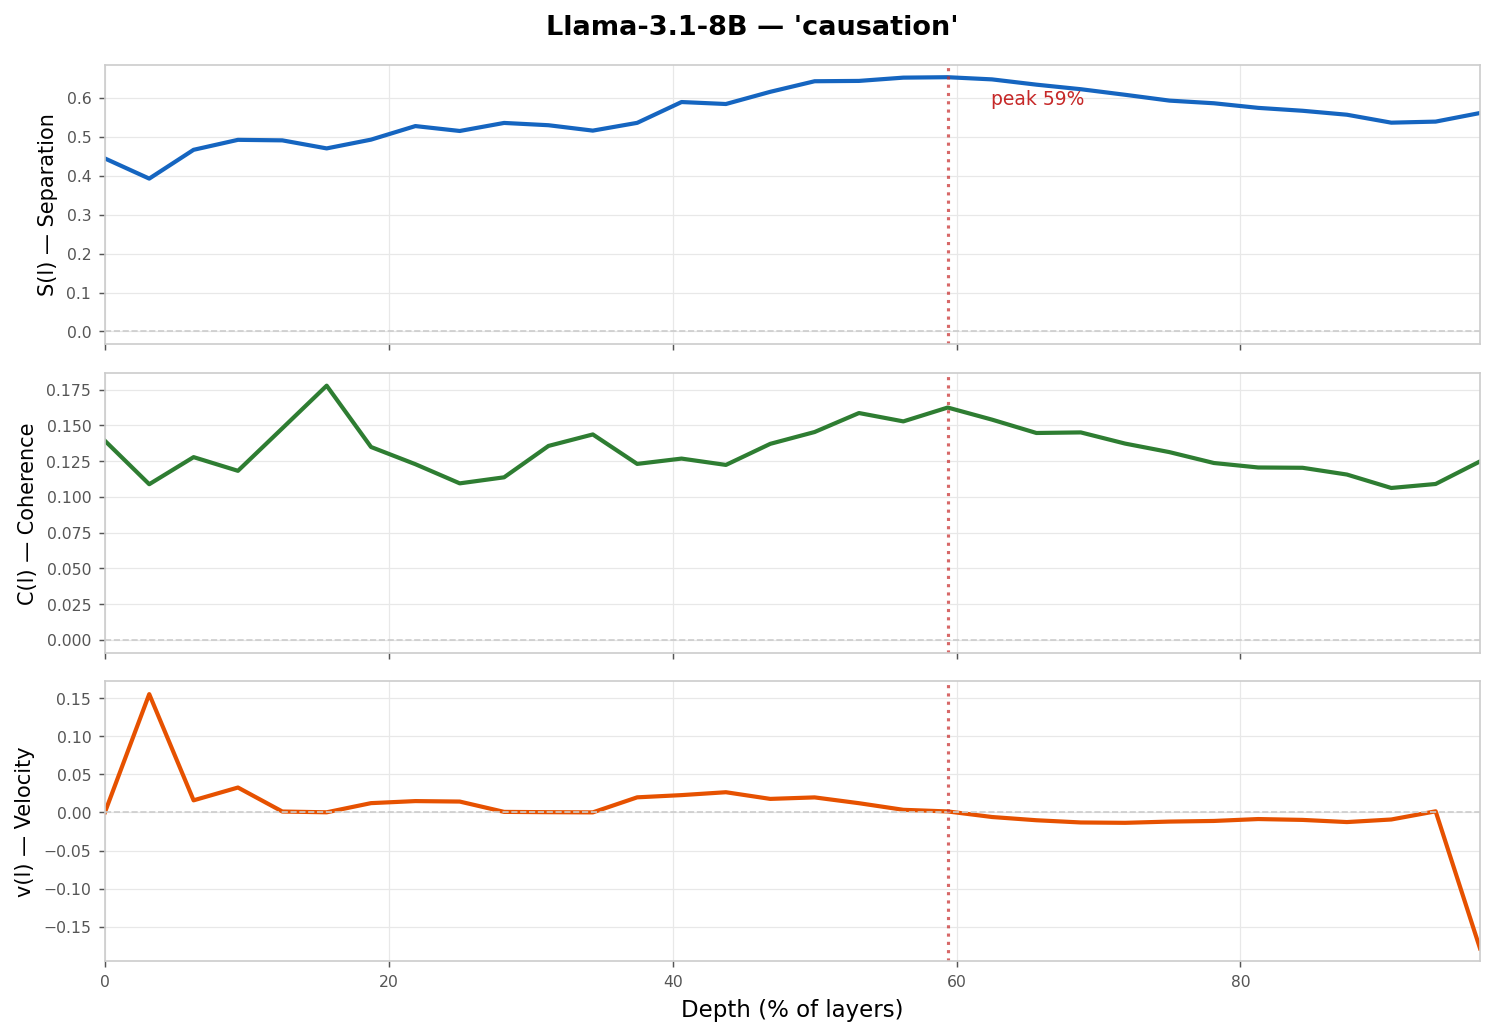

In [6]:
concept = "causation"
d = caz[concept]
metrics = d["layer_data"]["metrics"]
depth_x = [m["layer"] / d["n_layers"] * 100 for m in metrics]
max_depth = depth_x[-1]

SIG_COLORS = {"sep": "#1565C0", "coh": "#2E7D32", "vel": "#E65100"}

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.patch.set_facecolor("white")
fig.suptitle(f"{PRIMARY_LABEL} — '{concept}'", fontsize=13, fontweight="bold")

for ax, key, ylabel, color in zip(
    axes,
    ["separation_fisher", "coherence", "velocity"],
    ["S(l) — Separation", "C(l) — Coherence", "v(l) — Velocity"],
    [SIG_COLORS["sep"], SIG_COLORS["coh"], SIG_COLORS["vel"]],
):
    vals = [m[key] for m in metrics]
    ax.plot(depth_x, vals, color=color, lw=2)
    ax.axhline(0, color=THEME["spine"], lw=0.8, ls="--")
    ax.set_ylabel(ylabel, fontsize=10)
    apply_theme(ax)

peak_pct = d["layer_data"]["peak_depth_pct"]
for ax in axes:
    ax.axvline(peak_pct, color="#C62828", lw=1.5, ls=":", alpha=0.7)
axes[0].annotate(f"peak {peak_pct:.0f}%",
                 xy=(peak_pct, axes[0].get_ylim()[1]),
                 xytext=(peak_pct + 3, axes[0].get_ylim()[1] * 0.85),
                 color="#C62828", fontsize=9)
axes[-1].set_xlabel("Depth (% of layers)", fontsize=11)
axes[-1].set_xlim(0, max_depth)
plt.tight_layout()
plt.show()

**Velocity** (orange) peaks just *before* **separation** (blue) — it is the leading edge, marking where the model starts building the representation, not where it finishes. **Coherence** (green) rises and stays elevated, confirming the class geometry is genuinely organised rather than just having scattered centroids.

Together, the velocity rise marks the *onset* of assembly and the separation peak marks the *completion*. The region between them is the Concept Allocation Zone.

## 3. Zone anatomy

A CAZ is not just a peak — it has a **start**, a **peak**, and an **end**. `find_caz_regions` from `rosetta_tools` detects the full extent.

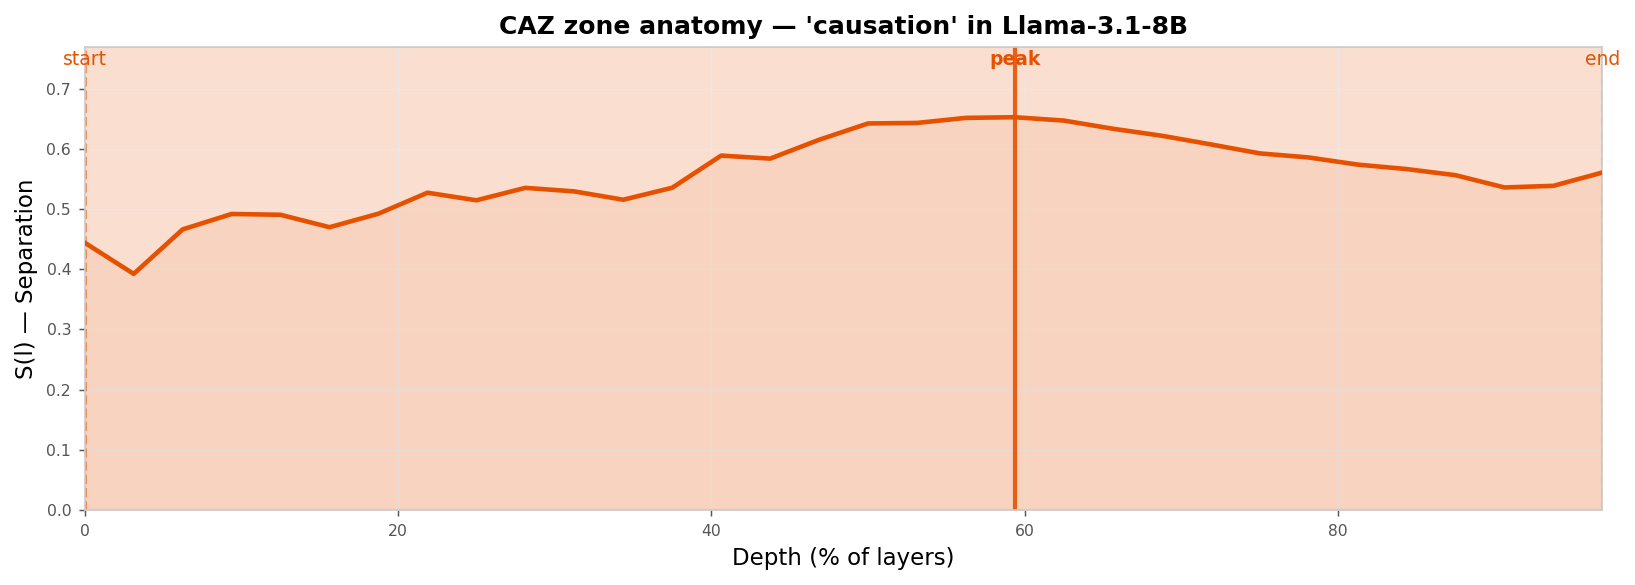

Zone: 0% → 59% (peak) → 97%   width = 97 pp


In [7]:
from rosetta_tools.caz import LayerMetrics, find_caz_regions

concept = "causation"
d = caz[concept]
metrics = d["layer_data"]["metrics"]
n_layers = d["n_layers"]
depth_x = [m["layer"] / n_layers * 100 for m in metrics]
sep     = [m["separation_fisher"] for m in metrics]
max_depth = depth_x[-1]

lm = [LayerMetrics(layer=m["layer"], separation=m["separation_fisher"],
                   coherence=m["coherence"], velocity=m["velocity"]) for m in metrics]
profile = find_caz_regions(lm)
region  = profile.dominant

s_pct = region.start / n_layers * 100
e_pct = region.end   / n_layers * 100
color = concept_color(concept)

fig, ax = plt.subplots(figsize=(11, 4))
fig.patch.set_facecolor("white")

ax.plot(depth_x, sep, color=color, lw=2.2, zorder=3)
ax.fill_between(depth_x, sep, alpha=0.08, color=color, zorder=2)
ax.axvspan(s_pct, e_pct, alpha=0.18, color=color, zorder=1)
ax.axvline(s_pct,              color=color, lw=1.2, ls="--", alpha=0.7)
ax.axvline(region.depth_pct,   color=color, lw=2.0, ls="-",  alpha=0.9)
ax.axvline(e_pct,              color=color, lw=1.2, ls="--", alpha=0.7)

ymax = max(sep) * 1.18
ax.text(s_pct,            ymax * 0.96, "start", color=color, fontsize=9, ha="center")
ax.text(region.depth_pct, ymax * 0.96, "peak",  color=color, fontsize=9, ha="center", fontweight="bold")
ax.text(e_pct,            ymax * 0.96, "end",   color=color, fontsize=9, ha="center")

ax.set_xlabel("Depth (% of layers)", fontsize=11)
ax.set_ylabel("S(l) — Separation", fontsize=11)
ax.set_ylim(0, ymax)
ax.set_xlim(0, max_depth)
ax.set_title(f"CAZ zone anatomy — '{concept}' in {PRIMARY_LABEL}", fontsize=12, fontweight="bold")
apply_theme(ax)
plt.tight_layout()
plt.show()
print(f"Zone: {s_pct:.0f}% → {region.depth_pct:.0f}% (peak) → {e_pct:.0f}%   width = {e_pct-s_pct:.0f} pp")

The shaded region is the zone extent — from where velocity first crosses threshold (start) to where separation drops off (end). The width reflects how precisely the concept is localised: a narrow zone means rapid, concentrated assembly; a wide zone means the process is distributed across many layers.

Zone width is not arbitrary. Across the evaluated concept set, width correlates with concept abstraction level at r = 0.294, p = 0.003: epistemic and affective concepts show systematically wider zones than relational and syntactic ones. More abstract concepts require more iterative construction across attention layers — the assembly process is literally longer (Henry 2026c §5.4; exploratory, n=6 concepts, researcher-assigned abstraction ranking).

This is **single-peak (unimodal) analysis** — one assembly event, one zone. Many concepts are unimodal. But some show two or more distinct peaks, and treating a multimodal concept as unimodal collapses two separate events into one noisy blur. That is the next section.

## 4. Multimodal allocation

Some concepts assemble in more than one event. Pythia-160M is the richest example in our dataset — 9 of 11 concepts are multimodal, with some reaching four distinct zones. The four panels below show the full spectrum: one zone through four.

caz_temporal_order.json: 0.00B [00:00, ?B/s]

caz_causation.json: 0.00B [00:00, ?B/s]

caz_agency.json: 0.00B [00:00, ?B/s]

caz_negation.json: 0.00B [00:00, ?B/s]

caz_sentiment.json: 0.00B [00:00, ?B/s]

...

caz_urgency.json: 0.00B [00:00, ?B/s]

caz_certainty.json: 0.00B [00:00, ?B/s]

caz_credibility.json: 0.00B [00:00, ?B/s]

caz_sarcasm.json: 0.00B [00:00, ?B/s]

caz_specificity.json: 0.00B [00:00, ?B/s]

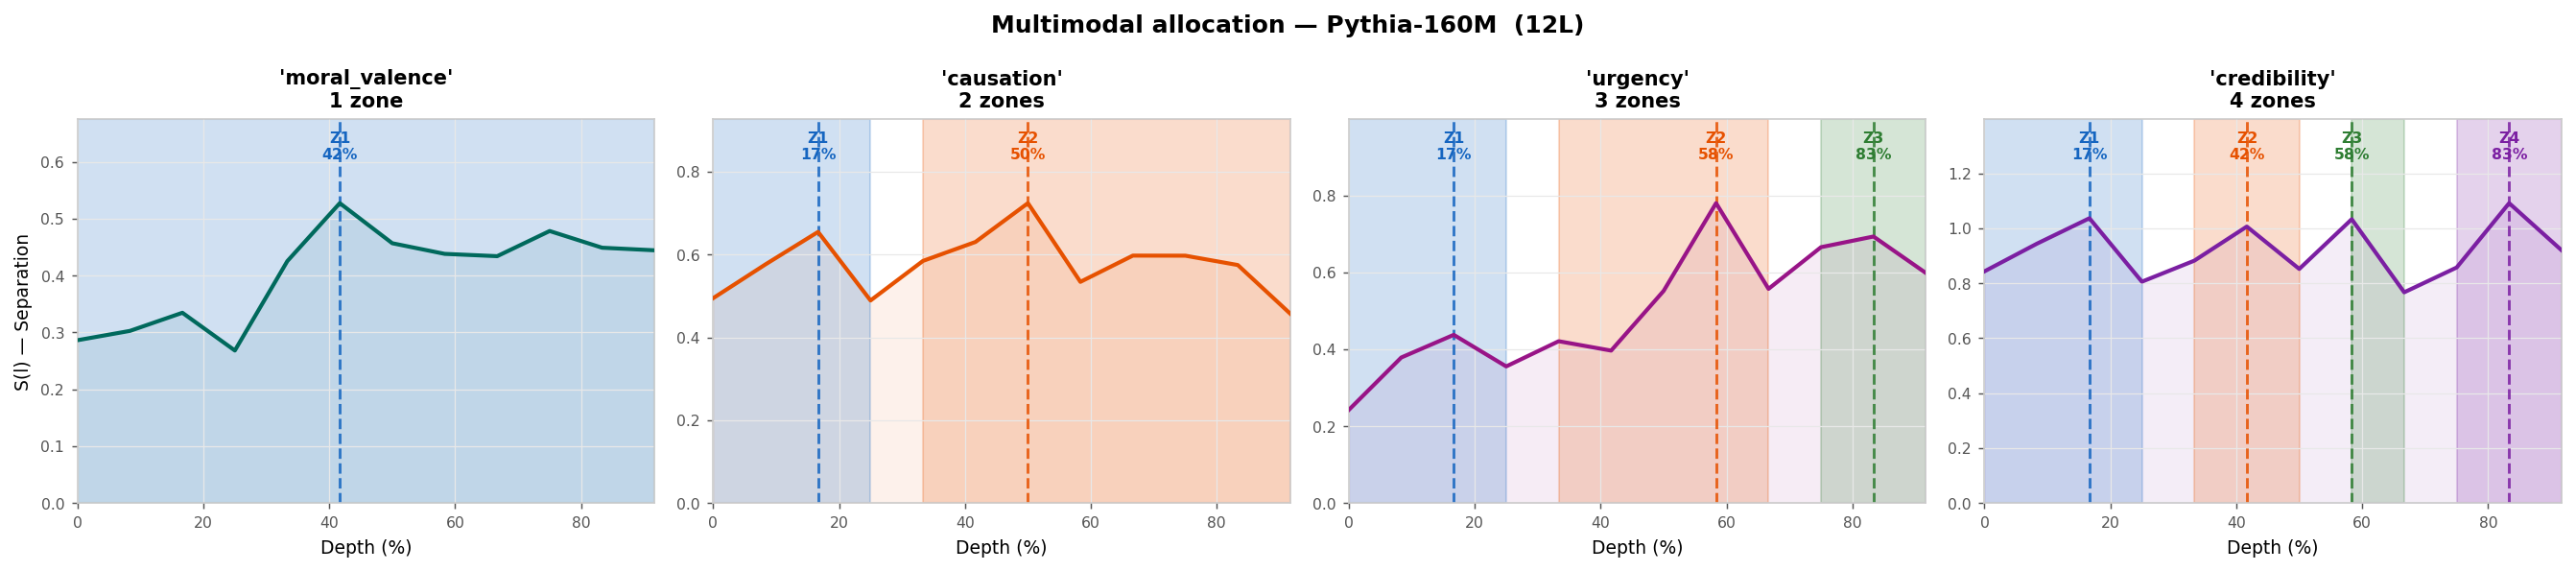

In [8]:
MULTIMODAL_MODEL = "EleutherAI/pythia-160m"
MULTIMODAL_LABEL = "Pythia-160M"

caz_p160m = {}
for concept in ALL_CONCEPTS:
    filename = f"{HF_DATA_ROOT}/{model_key(MULTIMODAL_MODEL)}/caz_{concept}.json"
    path = hf_hub_download(HF_REPO, filename=filename, repo_type="dataset")
    with open(path) as f:
        caz_p160m[concept] = json.load(f)

# 1 zone → 2 zones → 3 zones → 4 zones
DEMO_MM = ["moral_valence", "causation", "urgency", "credibility"]
ZONE_SHADE = ["#1565C0", "#E65100", "#2E7D32", "#7B1FA2"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
fig.patch.set_facecolor("white")
fig.suptitle(f"Multimodal allocation — {MULTIMODAL_LABEL}  (12L)",
             fontsize=12, fontweight="bold")

for ax, concept in zip(axes, DEMO_MM):
    d = caz_p160m[concept]
    metrics  = d["layer_data"]["metrics"]
    n_layers = d["n_layers"]
    depth_x  = [m["layer"] / n_layers * 100 for m in metrics]
    sep      = [m["separation_fisher"] for m in metrics]
    max_depth = depth_x[-1]

    lm = [LayerMetrics(layer=m["layer"], separation=m["separation_fisher"],
                       coherence=m["coherence"], velocity=m["velocity"]) for m in metrics]
    profile = find_caz_regions(lm)

    color = concept_color(concept)
    ax.plot(depth_x, sep, color=color, lw=2.0, zorder=3)
    ax.fill_between(depth_x, sep, alpha=0.08, color=color)

    ymax = max(sep) * 1.28
    for i, region in enumerate(profile.regions):
        s_pct = region.start / n_layers * 100
        e_pct = region.end   / n_layers * 100
        zc = ZONE_SHADE[i % len(ZONE_SHADE)]
        ax.axvspan(s_pct, e_pct, alpha=0.20, color=zc, zorder=1)
        ax.axvline(region.depth_pct, color=zc, lw=1.4, ls="--", alpha=0.85)
        ax.text(region.depth_pct, ymax * 0.97,
                f"Z{i+1}\n{region.depth_pct:.0f}%",
                ha="center", va="top", fontsize=7.5,
                color=zc, fontweight="bold", clip_on=False)

    n = profile.n_regions
    ax.set_title(f"'{concept}'\n{n} zone{'s' if n > 1 else ''}", fontsize=10, fontweight="bold")
    ax.set_xlabel("Depth (%)", fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel("S(l) — Separation", fontsize=9)
    ax.set_xlim(0, max_depth)
    ax.set_ylim(0, ymax)
    apply_theme(ax)

plt.tight_layout()
plt.show()

`moral_valence` (left) is unimodal — one clean assembly event. `causation` splits into two: a shallow pass and a deeper integration. `urgency` has three events spread across the full depth. `credibility` reaches four zones, peaking at roughly 17%, 42%, 58%, and 83% — assembling in overlapping phases rather than one coherent burst.

A probe positioned at any single layer captures at most one of `credibility`'s four events and misses the rest entirely.

**The peaks are not the same feature at different amplitudes.** Across 46 multimodal concept × model pairs (7 concepts; per-concept N ranging from 2 to 17), the per-concept mean cosine between the shallow-peak direction and the deep-peak direction falls in the range 0.156–0.433, with the cross-concept average in the 0.2–0.4 band (Henry, 2026c §4.2, Table 5). That is well above chance — random unit vectors in high-dimensional activation space average cosine ≈ 0.02 — but far from identical. The two assembly events are using geometrically distinct directions to separate the same contrastive classes. The code cell below verifies this directly for credibility in Pythia-160M using the pre-loaded dataset.

The paper interprets this as two *sub-representations* of the same concept: **shallow peaks**, near the embedding layers, are likely driven by lexical surface cues — concept-associated words present in the input text. **Deep peaks** are driven by compositional inference — scope, contextual reasoning, pragmatic implication. Both peaks separate positive from negative examples in the contrastive dataset. Neither is simply a louder version of the other.

In [9]:
# Inter-peak cosine for credibility in Pythia-160M — verifying geometric distinctness
_concept = "credibility"
_d = caz_p160m[_concept]
_metrics = _d["layer_data"]["metrics"]
_nl = _d["n_layers"]

_lm = [LayerMetrics(layer=m["layer"], separation=m["separation_fisher"],
                    coherence=m["coherence"], velocity=m["velocity"]) for m in _metrics]
_profile = find_caz_regions(_lm, min_prominence_frac=0.005)

print(f"Credibility in Pythia-160M: {_profile.n_regions} zones (scored 0.5% detection)")
print()
_cosines = []
for _i in range(_profile.n_regions - 1):
    _r1, _r2 = _profile.regions[_i], _profile.regions[_i + 1]
    _v1 = np.array(_metrics[_r1.peak]["dom_vector"])
    _v2 = np.array(_metrics[_r2.peak]["dom_vector"])
    _cos = abs(float(np.dot(_v1, _v2) / (np.linalg.norm(_v1) * np.linalg.norm(_v2) + 1e-12)))
    _cosines.append(_cos)
    print(f"  Z{_i+1} (peak {_r1.depth_pct:.0f}%) → Z{_i+2} (peak {_r2.depth_pct:.0f}%): cosine = {_cos:.3f}")

_hdim = _d["hidden_dim"]
print(f"\nChance baseline (random {_hdim}-dim vectors): ≈ {1/_hdim**0.5:.3f}")
print(f"Mean inter-peak cosine: {sum(_cosines)/len(_cosines):.3f}")
print("Correlated but distinct — same concept, different geometric sub-representations.")

Credibility in Pythia-160M: 4 zones (scored 0.5% detection)

  Z1 (peak 17%) → Z2 (peak 42%): cosine = 0.400
  Z2 (peak 42%) → Z3 (peak 58%): cosine = 0.542
  Z3 (peak 58%) → Z4 (peak 83%): cosine = 0.231

Chance baseline (random 768-dim vectors): ≈ 0.036
Mean inter-peak cosine: 0.391
Correlated but distinct — same concept, different geometric sub-representations.


## 5. Scored detection — the full picture

Sections 3 and 4 use `find_caz_regions` at its **default 10% prominence floor** — a local peak must rise at least 10% of the global maximum separation to register. This surfaces the dominant allocation events but misses a category the framework calls **gentle CAZes**: subtle allocation regions (score < 0.05) that are invisible under the default threshold but causally active in 93–100% of ablation tests across 26 base models (Henry, 2026a §6.2; Henry, 2026c §4.1).

The **CAZ score** replaces the binary threshold with a continuous composite:

$$\text{CAZ score} = \frac{\text{prominence}}{\bar{S}} \times \left(1 + \frac{C(l_{\text{peak}})}{\bar{C}}\right) \times \sqrt{\frac{\text{width}}{L}}$$

Prominence is normalized by the mean separation level; a coherence boost rewards geometrically organised peaks; a width term rewards wider, more sustained regions. Setting the floor to 0.5% and ranking by this score reveals the **full zone structure** — the paper's primary detection method.

The comparison below uses causation in Llama-3.1-8B. The default detector reports one zone (the dominant mid-depth peak from §3). The scored detector reveals two additional allocation events at shallower and deeper depths.

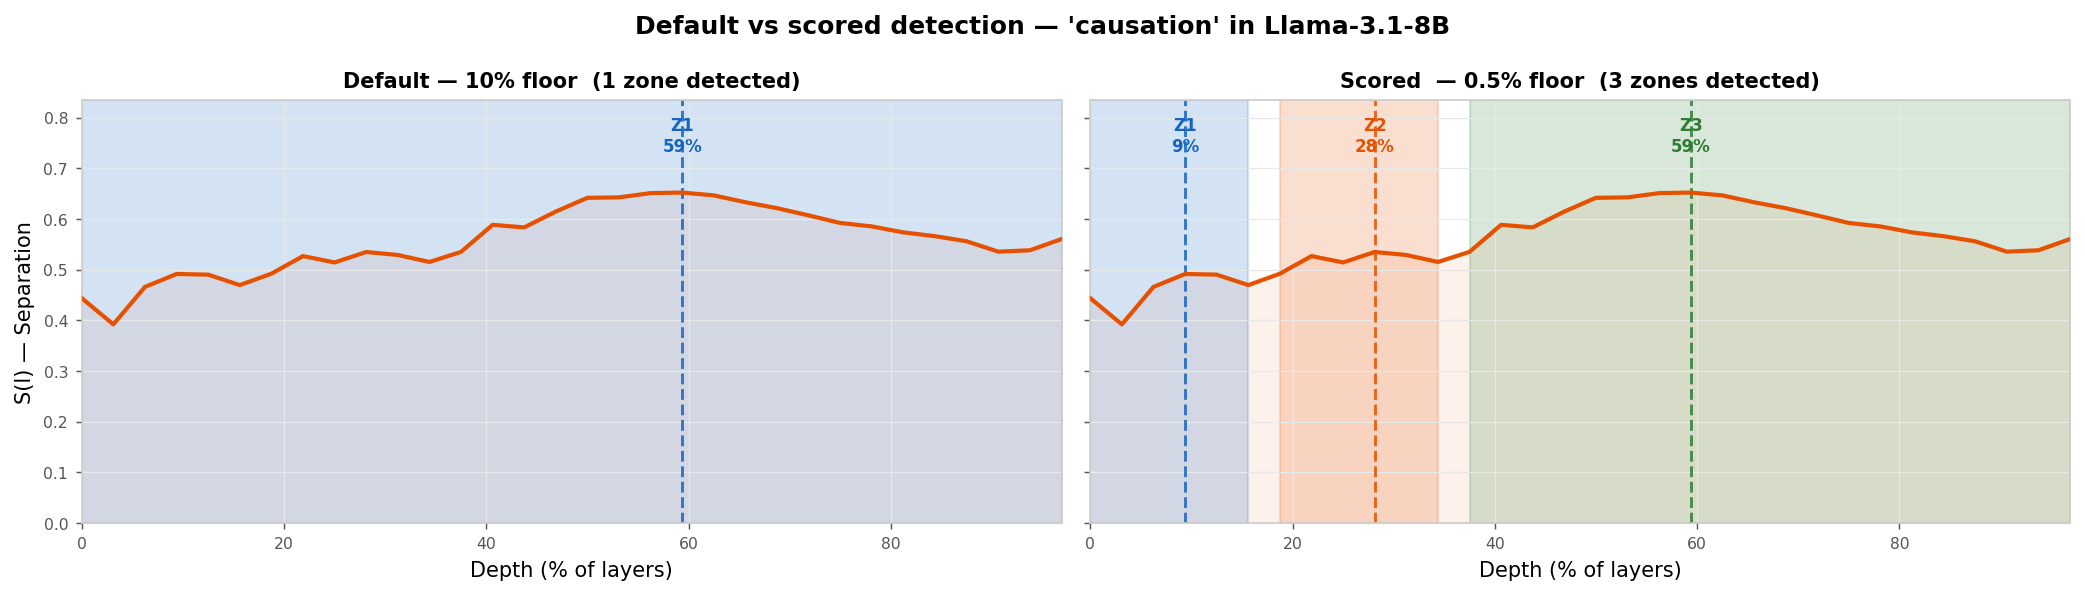


Default (10%): 1 zone(s)
  Z1: peak 59%  score=0.467  (strong)

Scored (0.5%): 3 zone(s)
  Z1: peak 9%  score=0.032  (gentle)
  Z2: peak 28%  score=0.062  (moderate)
  Z3: peak 59%  score=0.370  (strong)


In [10]:
# Default (10%) vs scored (0.5%) detection — causation in Llama-3.1-8B
_concept = "causation"
_d = caz[_concept]
_metrics = _d["layer_data"]["metrics"]
_nl = _d["n_layers"]
_depth_x = [m["layer"] / _nl * 100 for m in _metrics]
_sep      = [m["separation_fisher"] for m in _metrics]
_max_depth = _depth_x[-1]

_lm = [LayerMetrics(layer=m["layer"], separation=m["separation_fisher"],
                    coherence=m["coherence"], velocity=m["velocity"]) for m in _metrics]

_prof_default = find_caz_regions(_lm)                              # 10% floor
_prof_scored  = find_caz_regions(_lm, min_prominence_frac=0.005)  # 0.5% floor

_color      = concept_color(_concept)
ZONE_SHADE  = ["#1565C0", "#E65100", "#2E7D32", "#7B1FA2"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
fig.patch.set_facecolor("white")
fig.suptitle(
    f"Default vs scored detection — '{_concept}' in {PRIMARY_LABEL}",
    fontsize=12, fontweight="bold",
)

for ax, prof, label in zip(
    axes,
    [_prof_default, _prof_scored],
    [f"Default — 10% floor  ({_prof_default.n_regions} zone detected)",
     f"Scored  — 0.5% floor  ({_prof_scored.n_regions} zones detected)"],
):
    ax.plot(_depth_x, _sep, color=_color, lw=2.0, zorder=3)
    ax.fill_between(_depth_x, _sep, alpha=0.08, color=_color)
    _ymax = max(_sep) * 1.28
    for _i, _region in enumerate(prof.regions):
        _s = _region.start / _nl * 100
        _e = _region.end   / _nl * 100
        _zc = ZONE_SHADE[_i % len(ZONE_SHADE)]
        ax.axvspan(_s, _e, alpha=0.18, color=_zc)
        ax.axvline(_region.depth_pct, color=_zc, lw=1.4, ls="--", alpha=0.85)
        ax.text(_region.depth_pct, _ymax * 0.96,
                f"Z{_i+1}\n{_region.depth_pct:.0f}%",
                ha="center", va="top", fontsize=8,
                color=_zc, fontweight="bold", clip_on=False)
    ax.set_title(label, fontsize=10, fontweight="bold")
    ax.set_xlabel("Depth (% of layers)", fontsize=10)
    ax.set_xlim(0, _max_depth)
    ax.set_ylim(0, _ymax)
    apply_theme(ax)

axes[0].set_ylabel("S(l) — Separation", fontsize=10)
plt.tight_layout()
plt.show()

# Zone details with scores and category labels
def _cat(score):
    if score < 0.05:  return "gentle"
    if score < 0.2:   return "moderate"
    if score < 0.5:   return "strong"
    return "major"

for _prof, _label in [(_prof_default, "Default (10%)"), (_prof_scored, "Scored (0.5%)")]:
    print(f"\n{_label}: {_prof.n_regions} zone(s)")
    for _i, _r in enumerate(_prof.regions):
        print(f"  Z{_i+1}: peak {_r.depth_pct:.0f}%  score={_r.caz_score:.3f}  ({_cat(_r.caz_score)})")

The default detector sees one zone — the dominant peak at 59% depth (score 0.467, strong). The scored detector surfaces two additional zones: a gentle embedding-adjacent event at 9% depth (score 0.032) and a moderate secondary allocation at 28% depth (score 0.062). Both additions are genuine — across 26 base models, gentle CAZes detected at the 0.5% floor are causally active in 93–100% of ablation tests (Henry, 2026a §6.2; Henry, 2026c §4.1).

Category thresholds: **gentle** (score < 0.05) · **moderate** (0.05–0.2) · **strong** (0.2–0.5) · **major** (> 0.5). The companion paper (Henry, 2026a §6.2) reports the same comparison on GPT-2-XL: 7 concepts × default detection yields 7 zones; scored detection at 0.5% yields 10, with credibility, negation, and causation each revealing secondary allocation regions invisible under the standard threshold.

*This section adds to the paper rather than diverging from it: the concept demonstrated here (causation in Llama-3.1-8B) is not the paper's proof-of-concept example (GPT-2-XL), but the detection method and zone categories are identical.*

## 6. GEM — the direction also evolves

The sections above track *amplitude*: how strongly a concept is expressed at each layer. The **Geometric Evolution Map (GEM)** tracks the other half: which *direction* in activation space the concept occupies.

The dominant direction $\hat{d}(l)$ — the unit vector from negative to positive class centroid — rotates as representations are refined. The layer-to-layer cosine $\cos(\hat{d}_l,\, \hat{d}_{l-1})$ gives the **directional stability** $DS(l)$: values near 1.0 mean the direction barely moved; a sharp drop marks a **handoff point** where the geometric basis shifts.

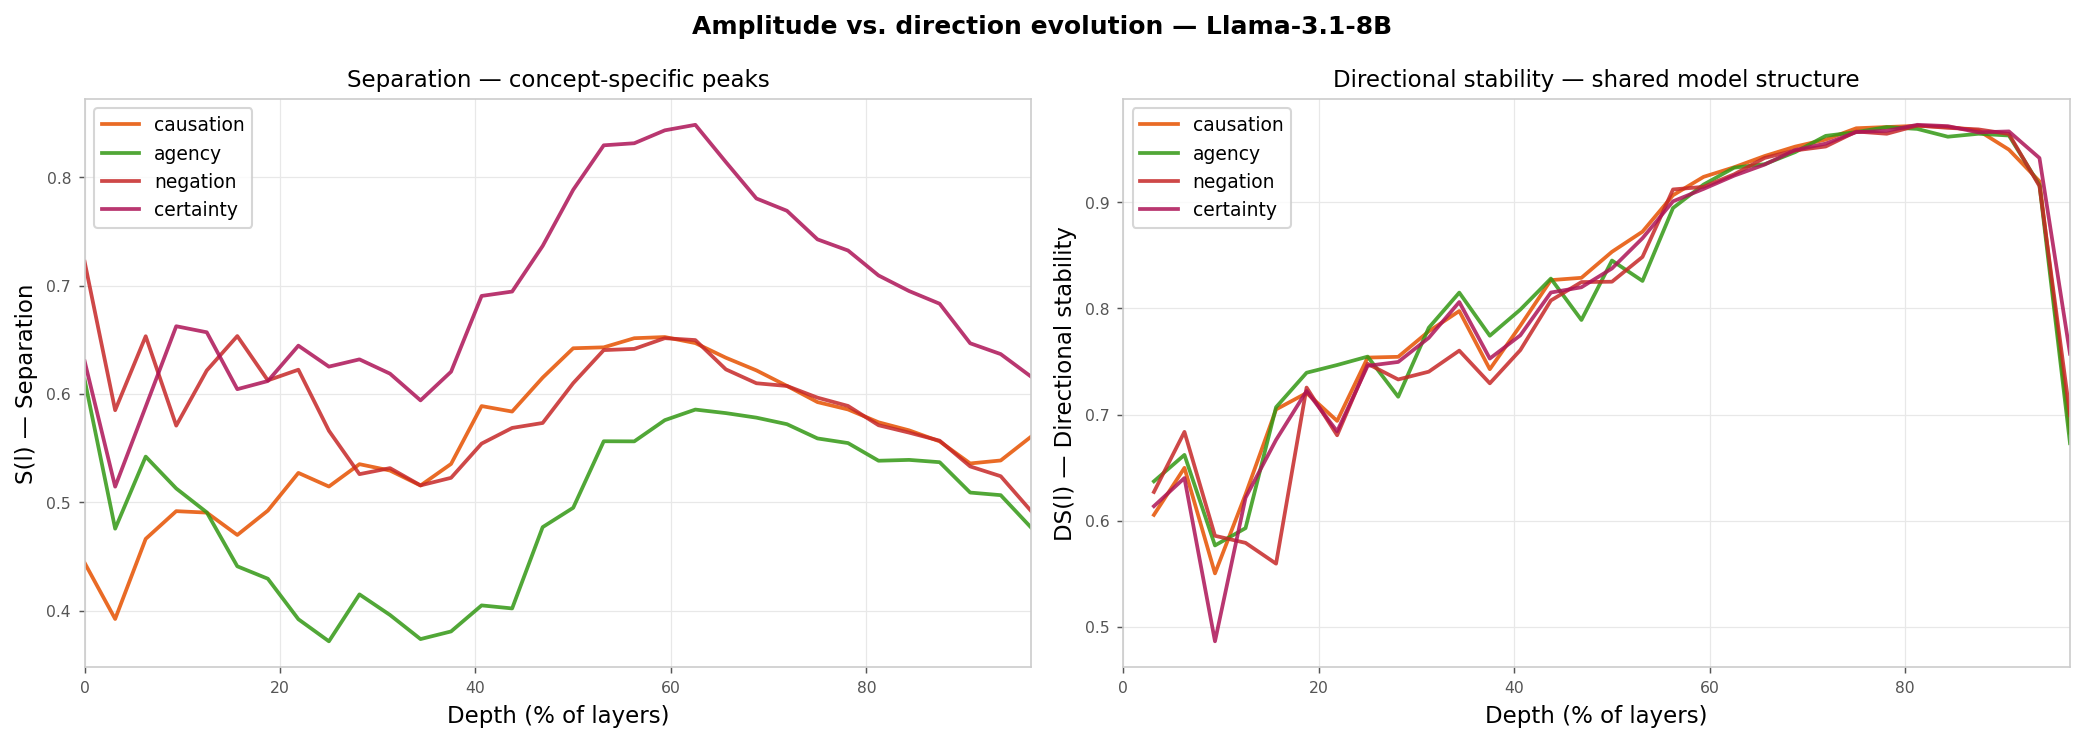

In [11]:
DEMO_CONCEPTS = ["causation", "agency", "negation", "certainty"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")
fig.suptitle(f"Amplitude vs. direction evolution — {PRIMARY_LABEL}",
             fontsize=12, fontweight="bold")

nl = caz[ALL_CONCEPTS[0]]["n_layers"]
depth_x = [l / nl * 100 for l in range(nl)]
max_depth = depth_x[-1]

for concept in DEMO_CONCEPTS:
    color   = concept_color(concept)
    metrics = caz[concept]["layer_data"]["metrics"]
    sep     = [m["separation_fisher"] for m in metrics]
    vecs    = [np.array(m["dom_vector"]) for m in metrics]

    dir_cos = [np.nan]
    for i in range(1, len(vecs)):
        v0, v1 = vecs[i-1], vecs[i]
        cos = float(np.dot(v0, v1) / (np.linalg.norm(v0) * np.linalg.norm(v1) + 1e-12))
        dir_cos.append(cos)

    label = concept.replace("_", " ")
    axes[0].plot(depth_x, sep,     color=color, lw=1.8, alpha=0.85, label=label)
    axes[1].plot(depth_x, dir_cos, color=color, lw=1.8, alpha=0.85, label=label)

axes[0].set_title("Separation — concept-specific peaks",          fontsize=11)
axes[0].set_ylabel("S(l) — Separation",                           fontsize=11)
axes[1].set_title("Directional stability — shared model structure", fontsize=11)
axes[1].set_ylabel("DS(l) — Directional stability",               fontsize=11)

for ax in axes:
    ax.set_xlabel("Depth (% of layers)", fontsize=11)
    ax.set_xlim(0, max_depth)
    ax.legend(fontsize=9, loc="upper left")
    apply_theme(ax)

plt.tight_layout()
plt.show()

The asymmetry is striking. **Separation** (left) peaks at different depths for each concept — the amplitude story is concept-specific. **Direction stability** (right) dips at the *same* layers for all four concepts — the handoff structure is a property of the model architecture, not of any individual concept.

Four semantically unrelated concepts — what a sentence *causes*, who *acts*, what is *negated*, what is *certain* — all undergo their geometric basis changes at the same moments. The model is not maintaining separate directional machinery for each concept. It has one shared transformation schedule that all semantic content moves through.

Look at the right panel carefully. The four curves are almost locked together: every dip, every recovery, every plateau is shared. At roughly 25% depth, all four concepts simultaneously lose directional stability — the geometric basis shifts beneath them all at once. The same happens at ~55% and again at ~80%. None of this is driven by what the concept *means*. It is driven by what the model *does* at each stage of processing.

**This is what it looks like when a model thinks.** The concept-specific peaks in the left panel tell you *what* the model is representing at each depth. The shared dips in the right panel reveal the underlying architecture of *how* it reorganises representations — the moments of structural transition that run underneath all semantic content simultaneously.

The core GEM insight: *where* a concept crystallises is concept-specific; *how* the model's geometric machinery transitions is shared infrastructure. The two signals decompose a model's internal activity into content and structure — and they evolve almost independently of each other.

caz_temporal_order.json: 0.00B [00:00, ?B/s]

caz_causation.json: 0.00B [00:00, ?B/s]

caz_agency.json: 0.00B [00:00, ?B/s]

caz_negation.json: 0.00B [00:00, ?B/s]

caz_sentiment.json: 0.00B [00:00, ?B/s]

...

caz_urgency.json: 0.00B [00:00, ?B/s]

caz_certainty.json: 0.00B [00:00, ?B/s]

caz_credibility.json: 0.00B [00:00, ?B/s]

caz_sarcasm.json: 0.00B [00:00, ?B/s]

caz_specificity.json: 0.00B [00:00, ?B/s]

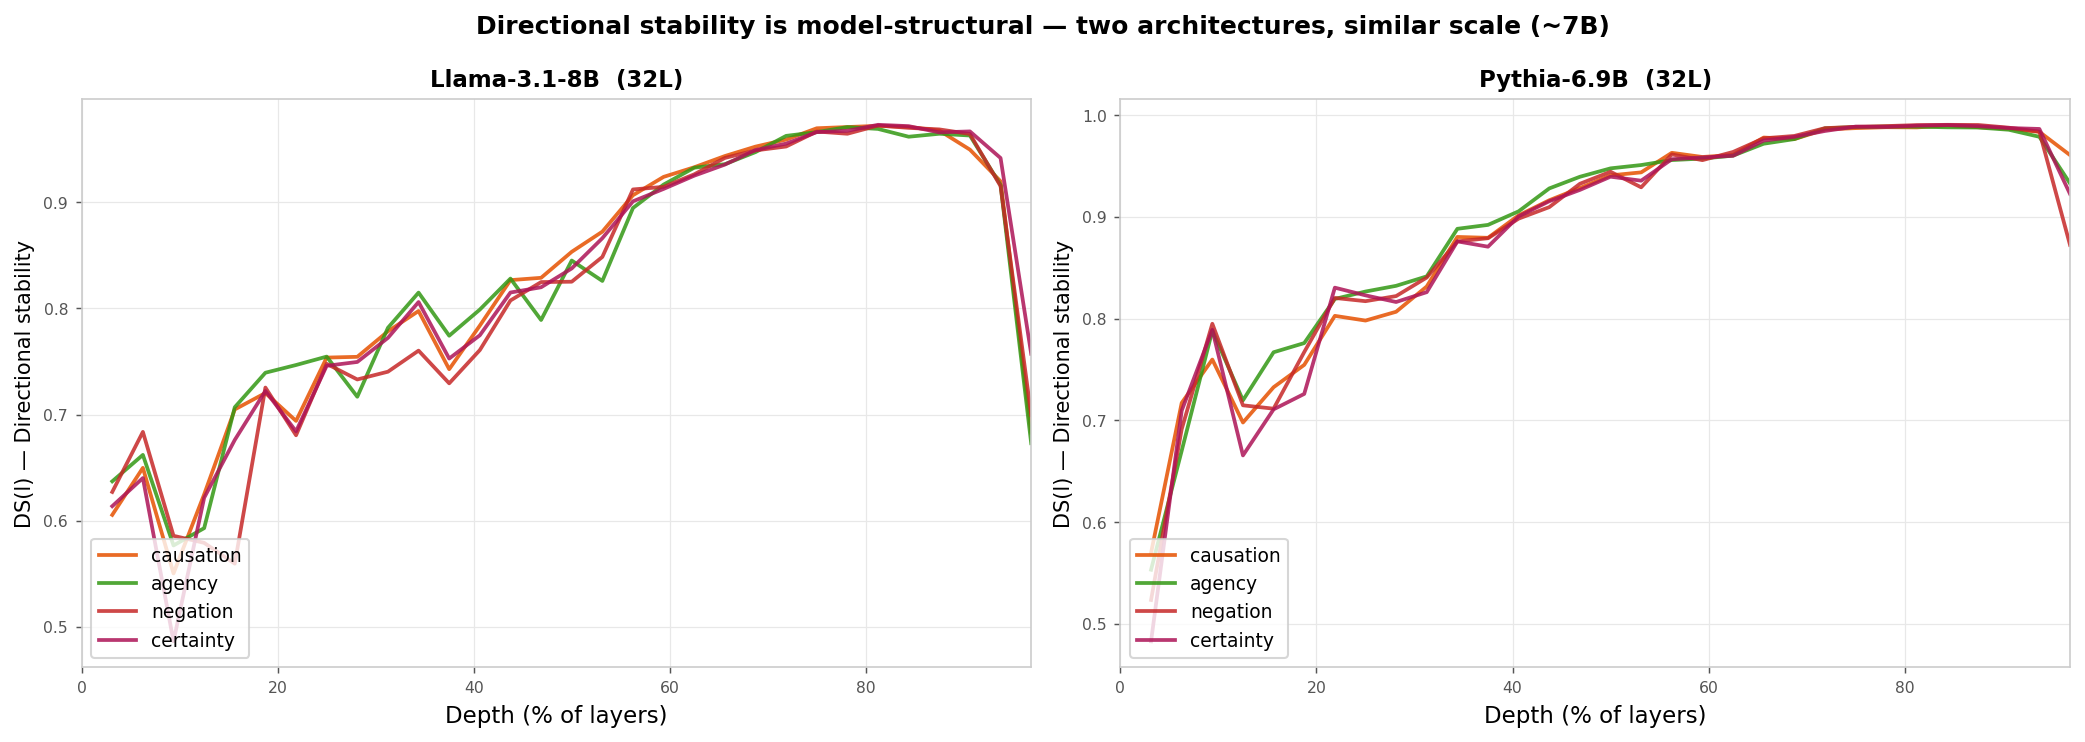

In [12]:
# Download Pythia-6.9B for size-matched comparison (~7B params — close to Llama-3.1-8B)
GEM_COMPARE_MODEL = "EleutherAI/pythia-6.9b"
GEM_COMPARE_LABEL = "Pythia-6.9B"

caz_p69b = {}
for concept in ALL_CONCEPTS:
    filename = f"{HF_DATA_ROOT}/{model_key(GEM_COMPARE_MODEL)}/caz_{concept}.json"
    path = hf_hub_download(HF_REPO, filename=filename, repo_type="dataset")
    with open(path) as f:
        caz_p69b[concept] = json.load(f)

DEMO_CONCEPTS = ["causation", "agency", "negation", "certainty"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("white")
fig.suptitle(
    "Directional stability is model-structural — two architectures, similar scale (~7B)",
    fontsize=12, fontweight="bold",
)

model_panels = [
    (caz,      PRIMARY_LABEL,      caz[ALL_CONCEPTS[0]]["n_layers"]),
    (caz_p69b, GEM_COMPARE_LABEL,  caz_p69b[ALL_CONCEPTS[0]]["n_layers"]),
]

for ax, (data, label, nl) in zip(axes, model_panels):
    max_depth = (nl - 1) / nl * 100
    depth_x   = [l / nl * 100 for l in range(nl)]

    for concept in DEMO_CONCEPTS:
        color   = concept_color(concept)
        metrics = data[concept]["layer_data"]["metrics"]
        vecs    = [np.array(m["dom_vector"]) for m in metrics]

        dir_cos = [np.nan]
        for i in range(1, len(vecs)):
            v0, v1 = vecs[i - 1], vecs[i]
            cos = float(np.dot(v0, v1) / (np.linalg.norm(v0) * np.linalg.norm(v1) + 1e-12))
            dir_cos.append(cos)

        ax.plot(depth_x, dir_cos, color=color, lw=1.8, alpha=0.85,
                label=concept.replace("_", " "))

    ax.set_title(f"{label}  ({nl}L)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Depth (% of layers)", fontsize=11)
    ax.set_ylabel("DS(l) — Directional stability", fontsize=10)
    ax.set_xlim(0, max_depth)
    ax.legend(fontsize=9, loc="lower left")
    apply_theme(ax)

plt.tight_layout()
plt.show()

The two panels use architectures from different design lineages — Llama-3.1-8B (GQA, SwiGLU, RoPE, 32 layers) and Pythia-6.9B (dense MHA, GELU, learned positional embeddings, 32 layers) — at roughly comparable parameter scale. Their handoff schedules differ: the specific depths at which geometric transitions occur are architecture-specific.

But in each panel, the four concept curves move together. Causation, agency, negation, and certainty share a handoff schedule not because of anything they have in common semantically — they share it because they are all passing through the *same model*. Every concept processed by a given architecture follows that architecture's structural rhythm.

This has a practical implication. When you observe a direction stability dip for a single concept, you cannot conclude that *this concept* is undergoing something special — you are observing the model's architectural machinery firing, which affects everything at once. To isolate a concept-specific signal, you need to subtract the shared structural baseline. GEM provides both the signal and its decomposition.

## 7. Concept topology — the full picture

With the vocabulary established, here is the complete concept topology of Pythia-160M — the model with the richest multimodal structure in the dataset. Bars span each zone's start-to-end extent; dots mark peaks; faded bars are secondary zones.

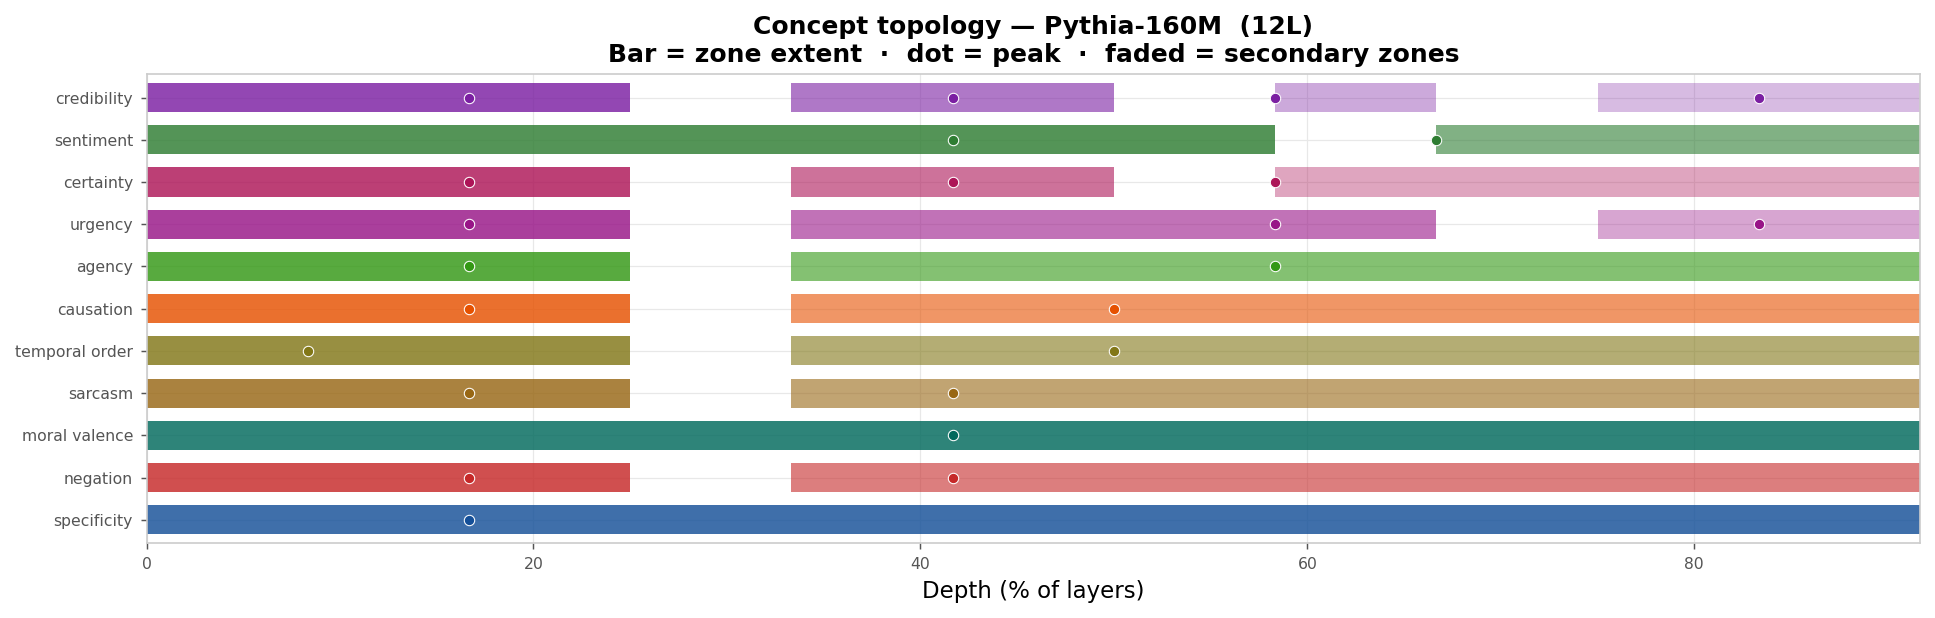

In [13]:
concept_order = sorted(ALL_CONCEPTS, key=lambda c: caz_p160m[c]["layer_data"]["peak_depth_pct"])

bar_h      = 0.22
row_gap    = 0.10
row_step   = bar_h + row_gap
n_rows     = len(concept_order)
fig_h      = n_rows * row_step + 0.70

fig, ax = plt.subplots(figsize=(13, fig_h))
fig.patch.set_facecolor("white")

_n_layers = None
for ci, concept in enumerate(concept_order):
    y = ci * row_step
    d = caz_p160m[concept]
    n_layers = d["n_layers"]
    if _n_layers is None:
        _n_layers = n_layers
    metrics  = d["layer_data"]["metrics"]
    lm = [LayerMetrics(layer=m["layer"], separation=m["separation_fisher"],
                       coherence=m["coherence"], velocity=m["velocity"]) for m in metrics]
    profile = find_caz_regions(lm)
    color = concept_color(concept)

    for i, region in enumerate(profile.regions):
        s_pct = region.start / n_layers * 100
        e_pct = region.end   / n_layers * 100
        alpha = max(0.82 - i * 0.22, 0.30)
        ax.barh(y, e_pct - s_pct, left=s_pct, height=bar_h,
                color=color, alpha=alpha, zorder=2)
        ax.plot(region.depth_pct, y, "o", color=color, ms=5, zorder=3,
                markeredgecolor="white", markeredgewidth=0.5)

max_depth = (_n_layers - 1) / _n_layers * 100

y_positions = [ci * row_step for ci in range(n_rows)]
ax.set_yticks(y_positions)
ax.set_yticklabels([c.replace("_", " ") for c in concept_order], fontsize=10)
ax.set_ylim(-bar_h * 0.8, (n_rows - 1) * row_step + bar_h * 0.8)
ax.set_xlabel("Depth (% of layers)", fontsize=11)
ax.set_xlim(0, max_depth)
ax.set_title(f"Concept topology — {MULTIMODAL_LABEL}  ({_n_layers}L)\n"
             "Bar = zone extent  ·  dot = peak  ·  faded = secondary zones",
             fontsize=12, fontweight="bold")
apply_theme(ax)
plt.tight_layout()
plt.show()

The topology of a single model is not anomalous. Across 34 models from 8 architectural families (26 base, 8 instruct), scored detection (0.5% floor) yields a **mean of ~2.5 CAZes per concept per model** — multimodal allocation is the default, not the exception (Henry, 2026a §4.2; Henry, 2026c §4.2). Pythia-160M is the richest example in the pre-loaded dataset, but every concept evaluated shows multimodality in at least some models.

**Width reflects abstraction.** The width variation visible in the chart is statistically meaningful. Zone width correlates with concept abstraction level at r = 0.294, p = 0.003: epistemic and affective concepts show wider zones than relational and syntactic ones (Henry 2026c §5.4; exploratory, n=6 concepts, researcher-assigned abstraction ranking). The longer bars in this chart are not noisier — they are concepts that require more iterative assembly across layers to crystallise.

**Zones are causally active, not just geometrically prominent.** Ablation at detected CAZ peaks produces **3.67× greater concept suppression** on average than ablation at matched non-CAZ control layers (Henry, 2026c §6.1). The topology is not a map of where concepts look most organised — it is a map of where the model is doing the most concept-relevant computation.

**Layers are shared across concepts.** 48% of CAZ layers host two or more concepts peaking simultaneously (Henry, 2026a §6). The topology appears concept-specific, but the geometry beneath it is shared infrastructure — the model allocates directions to multiple concepts within overlapping depth windows.

**This chart shows the visible structure.** The bars above are zones detected at the default prominence threshold. Scored detection with a 0.5% floor recovers 3.1× more structure: 51% of all detected zones across 26 models are "gentle" CAZes (score < 0.05), invisible to standard peak-finding but causally active in 93–100% of ablation tests (Henry, 2026c §4.1). The full concept topology — including the gentle layer — is substantially denser than what any threshold-based method surfaces.

## Summary

| Section | What we covered |
|---------|----------------|
| 1. Single-layer problem | Concept representations build continuously across many layers; a single-layer probe (or SAE) captures one slice of a longer construction process |
| 2. Three signals | $S(l)$, $C(l)$, $v(l)$ — amplitude, organisation, and rate of change |
| 3. Zone anatomy | CAZ zones have start, peak, and end; width reflects how precisely a concept is localised |
| 4. Multimodal allocation | Some concepts assemble in multiple events; a single probe misses all but one |
| 5. Scored detection | 0.5% floor and CAZ score reveal gentle CAZes invisible to standard peak detection |
| 6. GEM | $DS(l)$ tracks direction rotation layer-by-layer; handoff dips are model-structural, not concept-specific |
| 7. Concept topology | A full portrait of one model's internal concept landscape |

---

### Next notebooks

| Notebook | What it covers |
|----------|---------------|
| `02_caz_interactive_demo.ipynb` | Load Qwen2.5-7B (4-bit) and run CAZ on your own concept pairs |
| `03_caz_implementation_demo.ipynb` | Implement the metrics from scratch; reproduce the cross-architecture convergence result from Paper 4 |

### Papers and resources

| | |
|-|-|
| Paper 1 — CAZ Framework | [Henry 2026a](https://arxiv.org/abs/PLACEHOLDER) |
| Paper 2 — GEM | [Henry 2026b](https://arxiv.org/abs/PLACEHOLDER) |
| `rosetta_tools` | [GitHub](https://github.com/jamesrahenry/Rosetta_Tools) |
| Concept pairs dataset | [Rosetta_Concept_Pairs](https://github.com/jamesrahenry/Rosetta_Concept_Pairs) |